In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
production = pd.read_csv("Dataset_weather.csv",
                        usecols=(lambda s: s.startswith('utc') | s.startswith('DE')),
                        parse_dates=[0], index_col=0)

In [3]:
production


,DE_wind_generation_actual,DE_solar_generation_actual
utc_timestamp,,
2016-01-01 00:00:00+00:00,8579.0,0.0
2016-01-01 01:00:00+00:00,8542.0,0.0
2016-01-01 02:00:00+00:00,8443.0,0.0
2016-01-01 03:00:00+00:00,8295.0,0.0
2016-01-01 04:00:00+00:00,7319.0,0.0
...,...,...
2016-12-31 19:00:00+00:00,15303.0,0.0
2016-12-31 20:00:00+00:00,15354.0,0.0
2016-12-31 21:00:00+00:00,14847.0,0.0


In [4]:
production.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8711 entries, 2016-01-01 00:00:00+00:00 to 2016-12-31 23:00:00+00:00
Data columns (total 2 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   DE_wind_generation_actual   8711 non-null   float64
 1   DE_solar_generation_actual  8711 non-null   float64
dtypes: float64(2)
memory usage: 204.2 KB


(16801.0, 17167.0)

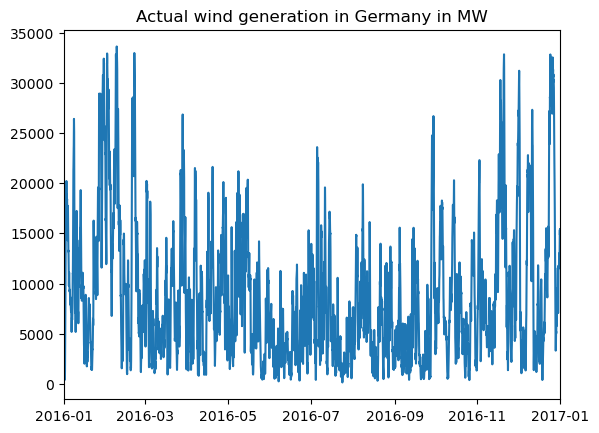

In [5]:
plt.plot(production.index, production['DE_wind_generation_actual'])
plt.title('Actual wind generation in Germany in MW')
plt.xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2017-01-01'))

# save plot
#plt.savefig("figs/wind.png", dpi=200)

(16801.0, 17167.0)

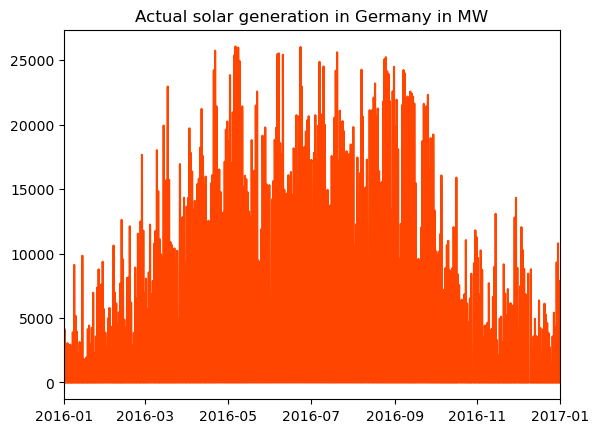

In [6]:
plt.plot(production.index, production['DE_solar_generation_actual'], c='OrangeRed')
plt.title('Actual solar generation in Germany in MW')
plt.xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2017-01-01'))

# save plot
#plt.savefig("figs/solar.png", dpi=200)

In [7]:
production_wind_solar = production[['DE_wind_generation_actual', 'DE_solar_generation_actual']]


In [8]:
weather = pd.read_csv("Dataset_weather.csv",
                     parse_dates=[0], index_col=0)

In [9]:
weather

,DE_wind_generation_actual,DE_solar_generation_actual,v1,v2,v_50m,h1,h2,z0,SWTDN,SWGDN,...,humidity,dew,windspeed,winddir,pressure,visibility,cloudcover,conditions,skyType,total_renewable_generation
utc_timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00+00:00,8579.0,0.0,2.616758,3.714414,5.132500,2.546875,10.546875,0.164370,0.0,0.0,...,100.00,1.9,4.4,180.0,NaN,0.4,98.4,Overcast,1.0,8579.0
2016-01-01 01:00:00+00:00,8542.0,0.0,2.564375,3.631055,4.976094,2.546875,10.546875,0.164331,0.0,0.0,...,93.62,1.9,5.6,196.0,NaN,0.3,59.2,Partially cloudy,2.0,8542.0
2016-01-01 02:00:00+00:00,8443.0,0.0,2.480859,3.516328,4.794688,2.546875,10.546875,0.164288,0.0,0.0,...,94.10,2.0,6.7,230.0,NaN,1.1,98.4,Overcast,1.0,8443.0
2016-01-01 03:00:00+00:00,8295.0,0.0,2.397148,3.404961,4.664023,2.546875,10.546875,0.164239,0.0,0.0,...,94.06,1.1,5.1,218.0,NaN,1.3,98.4,Overcast,1.0,8295.0
2016-01-01 04:00:00+00:00,7319.0,0.0,2.305703,3.286602,4.566289,2.546875,10.546875,0.164199,0.0,0.0,...,93.61,1.0,1.9,202.0,NaN,2.1,13.8,Clear,0.0,7319.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-31 19:00:00+00:00,15303.0,0.0,3.684609,5.233516,7.098086,2.550781,10.550781,0.164608,0.0,0.0,...,98.45,1.6,15.0,240.0,NaN,3.9,98.4,Overcast,1.0,15303.0
2016-12-31 20:00:00+00:00,15354.0,0.0,3.762305,5.307539,7.083867,2.550781,10.550781,0.164577,0.0,0.0,...,98.46,1.7,14.2,239.0,NaN,4.3,98.4,Overcast,1.0,15354.0
2016-12-31 21:00:00+00:00,14847.0,0.0,3.792852,5.340195,7.122773,2.546875,10.546875,0.164536,0.0,0.0,...,92.66,1.9,16.6,244.0,NaN,8.0,98.4,Overcast,1.0,14847.0


In [12]:
weather_by_day = weather.select_dtypes(include='number').groupby(weather.index.date).mean()

In [13]:
weather_by_day

,DE_wind_generation_actual,DE_solar_generation_actual,v1,v2,v_50m,h1,h2,z0,SWTDN,SWGDN,...,temp,humidity,dew,windspeed,winddir,pressure,visibility,cloudcover,skyType,total_renewable_generation
2016-01-01,4467.041667,773.416667,2.095762,3.033911,4.237871,2.544108,10.544108,0.163908,80.401818,25.681694,...,1.529167,97.713750,1.195833,5.954167,228.375000,NaN,1.941667,85.795833,1.208333,5240.458333
2016-01-02,17067.458333,391.791667,4.902622,6.815675,8.677072,2.542969,10.542969,0.163165,80.983138,22.993594,...,-3.675000,83.094583,-6.258333,22.750000,94.041667,NaN,6.479167,91.320833,1.500000,17459.250000
2016-01-03,16929.041667,563.291667,5.180228,7.167840,8.966387,2.542969,10.542969,0.162304,81.621492,28.362907,...,-9.912500,74.890000,-13.570833,24.358333,101.541667,NaN,9.995833,39.316667,1.041667,17492.333333
2016-01-04,11602.541667,420.000000,4.475280,6.248237,8.154238,2.532878,10.532878,0.161322,82.314810,21.650383,...,-9.275000,71.326250,-13.575000,18.241667,92.375000,NaN,9.533333,25.875000,0.583333,12022.541667
2016-01-05,8602.833333,522.916667,3.747306,5.254022,7.054144,2.531250,10.531250,0.160388,83.064642,24.028294,...,-8.270833,78.363750,-11.420833,15.641667,80.083333,NaN,5.216667,66.175000,1.250000,9125.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-27,26704.083333,977.000000,5.639372,8.098896,10.941558,2.568848,10.568848,0.168389,78.543984,33.945533,...,6.245833,71.794583,1.420833,29.525000,294.958333,NaN,10.000000,73.941667,1.750000,27681.083333
2016-12-28,8957.791667,810.333333,2.807549,4.217238,6.040954,2.565267,10.565267,0.167409,78.887679,28.686128,...,5.962500,93.608333,5.008333,11.225000,318.500000,NaN,9.412500,89.183333,1.958333,9768.125000
2016-12-29,6987.458333,1787.916667,2.310716,3.507181,5.203285,2.557454,10.557454,0.166578,79.287082,44.985086,...,3.479167,90.365000,1.987500,6.958333,246.375000,NaN,9.758333,59.062500,1.416667,8775.375000
2016-12-30,9968.875000,2022.750000,2.631130,3.767054,5.339451,2.554688,10.554688,0.165726,79.742655,50.146608,...,-0.233333,92.915833,-1.300000,6.554167,204.666667,NaN,9.020833,0.925000,0.000000,11991.625000


(16801.0, 17167.0)

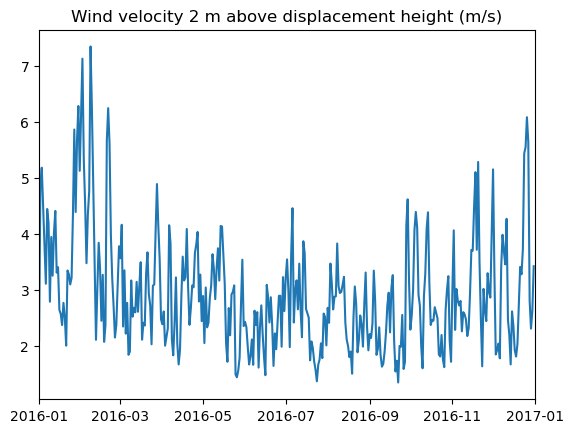

In [14]:
plt.plot(weather_by_day.index, weather_by_day['v1'])
plt.title('Wind velocity 2 m above displacement height (m/s)')
plt.xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2017-01-01'))

# save plot
#plt.savefig("figs/v1.png", dpi=200)

(16801.0, 17167.0)

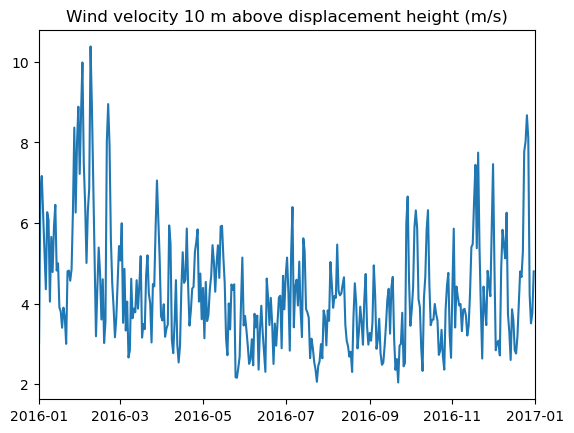

In [15]:
plt.plot(weather_by_day.index, weather_by_day['v2'])
plt.title('Wind velocity 10 m above displacement height (m/s)')
plt.xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2017-01-01'))

# save plot
#plt.savefig("figs/v2.png", dpi=200)

(16801.0, 17167.0)

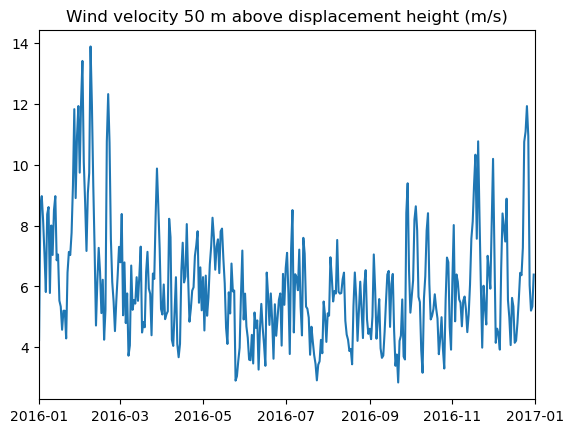

In [16]:
plt.plot(weather_by_day.index, weather_by_day['v_50m'])
plt.title('Wind velocity 50 m above displacement height (m/s)')
plt.xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2017-01-01'))

#plt.savefig("figs/v_50m.png", dpi=200)

(16801.0, 17167.0)

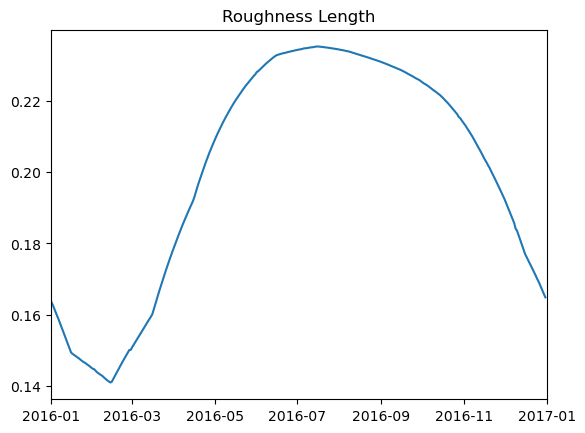

In [17]:
plt.plot(weather_by_day.index, weather_by_day['z0'])
plt.title('Roughness Length')
plt.xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2017-01-01'))

#plt.savefig("figs/z0.png", dpi=200)

(16801.0, 17167.0)

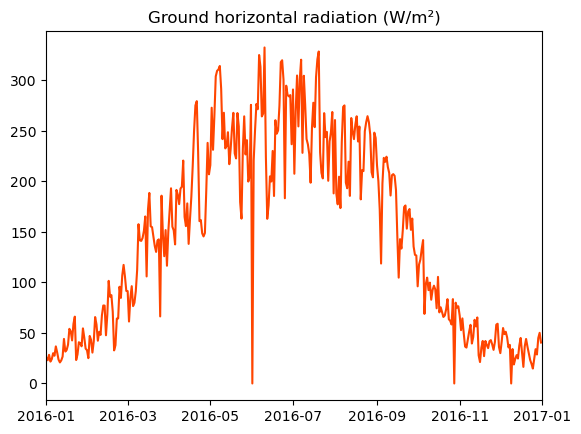

In [18]:
plt.plot(weather_by_day.index, weather_by_day['SWGDN'], c='OrangeRed')
plt.title('Ground horizontal radiation (W/m²)')
plt.xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2017-01-01'))

# save plot
#plt.savefig("figs/radiation.png", dpi=200)

(16801.0, 17167.0)

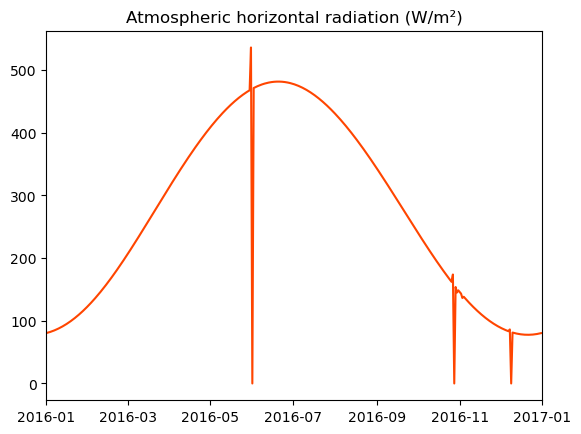

In [19]:
plt.plot(weather_by_day.index, weather_by_day['SWTDN'], c='OrangeRed')
plt.title('Atmospheric horizontal radiation (W/m²)')
plt.xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2017-01-01'))

# save plot
#plt.savefig("figs/atomspheric-radiation.png", dpi=200)

(16801.0, 17167.0)

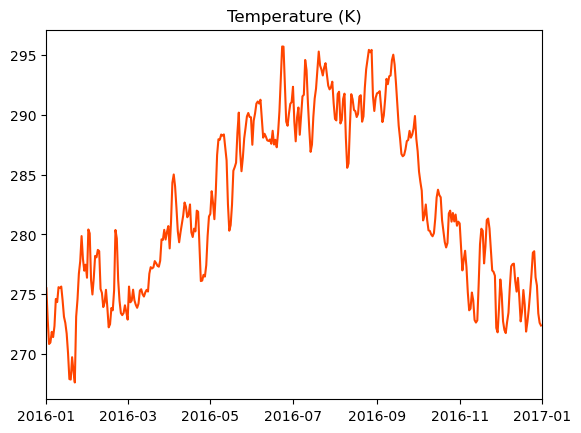

In [20]:
plt.plot(weather_by_day.index, weather_by_day['T'], c='OrangeRed')
plt.title('Temperature (K)')
plt.xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2017-01-01'))

# save plot
#plt.savefig("figs/temperature_K.png", dpi=200)

In [21]:
weather_forecast_data = pd.read_csv('Dataset_weather.csv', parse_dates=[0])

In [22]:
weather_forecast_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8711 entries, 0 to 8710
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype              
---  ------                      --------------  -----              
 0   utc_timestamp               8711 non-null   datetime64[ns, UTC]
 1   DE_wind_generation_actual   8711 non-null   float64            
 2   DE_solar_generation_actual  8711 non-null   float64            
 3   v1                          8711 non-null   float64            
 4   v2                          8711 non-null   float64            
 5   v_50m                       8711 non-null   float64            
 6   h1                          8711 non-null   float64            
 7   h2                          8711 non-null   float64            
 8   z0                          8711 non-null   float64            
 9   SWTDN                       8711 non-null   float64            
 10  SWGDN                       8711 non-null   float64         

In [23]:
weather

,DE_wind_generation_actual,DE_solar_generation_actual,v1,v2,v_50m,h1,h2,z0,SWTDN,SWGDN,...,humidity,dew,windspeed,winddir,pressure,visibility,cloudcover,conditions,skyType,total_renewable_generation
utc_timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00+00:00,8579.0,0.0,2.616758,3.714414,5.132500,2.546875,10.546875,0.164370,0.0,0.0,...,100.00,1.9,4.4,180.0,NaN,0.4,98.4,Overcast,1.0,8579.0
2016-01-01 01:00:00+00:00,8542.0,0.0,2.564375,3.631055,4.976094,2.546875,10.546875,0.164331,0.0,0.0,...,93.62,1.9,5.6,196.0,NaN,0.3,59.2,Partially cloudy,2.0,8542.0
2016-01-01 02:00:00+00:00,8443.0,0.0,2.480859,3.516328,4.794688,2.546875,10.546875,0.164288,0.0,0.0,...,94.10,2.0,6.7,230.0,NaN,1.1,98.4,Overcast,1.0,8443.0
2016-01-01 03:00:00+00:00,8295.0,0.0,2.397148,3.404961,4.664023,2.546875,10.546875,0.164239,0.0,0.0,...,94.06,1.1,5.1,218.0,NaN,1.3,98.4,Overcast,1.0,8295.0
2016-01-01 04:00:00+00:00,7319.0,0.0,2.305703,3.286602,4.566289,2.546875,10.546875,0.164199,0.0,0.0,...,93.61,1.0,1.9,202.0,NaN,2.1,13.8,Clear,0.0,7319.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-31 19:00:00+00:00,15303.0,0.0,3.684609,5.233516,7.098086,2.550781,10.550781,0.164608,0.0,0.0,...,98.45,1.6,15.0,240.0,NaN,3.9,98.4,Overcast,1.0,15303.0
2016-12-31 20:00:00+00:00,15354.0,0.0,3.762305,5.307539,7.083867,2.550781,10.550781,0.164577,0.0,0.0,...,98.46,1.7,14.2,239.0,NaN,4.3,98.4,Overcast,1.0,15354.0
2016-12-31 21:00:00+00:00,14847.0,0.0,3.792852,5.340195,7.122773,2.546875,10.546875,0.164536,0.0,0.0,...,92.66,1.9,16.6,244.0,NaN,8.0,98.4,Overcast,1.0,14847.0


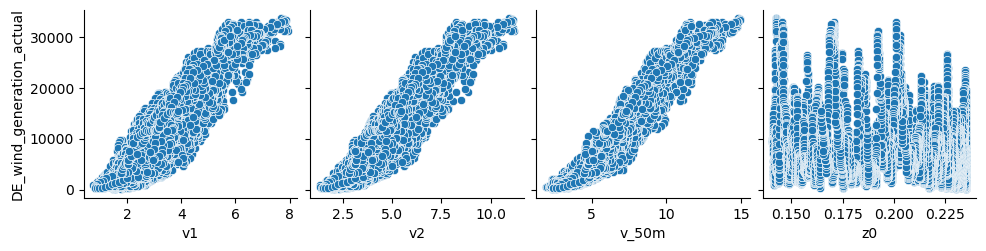

In [24]:
sns.pairplot(weather, x_vars=['v1', 'v2', 'v_50m', 'z0'], y_vars=['DE_wind_generation_actual'])


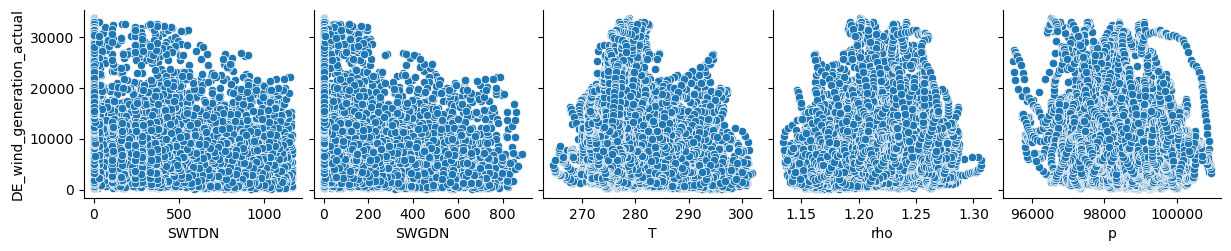

In [25]:
sns.pairplot(weather, x_vars=['SWTDN', 'SWGDN', 'T', 'rho', 'p'], y_vars=['DE_wind_generation_actual'])


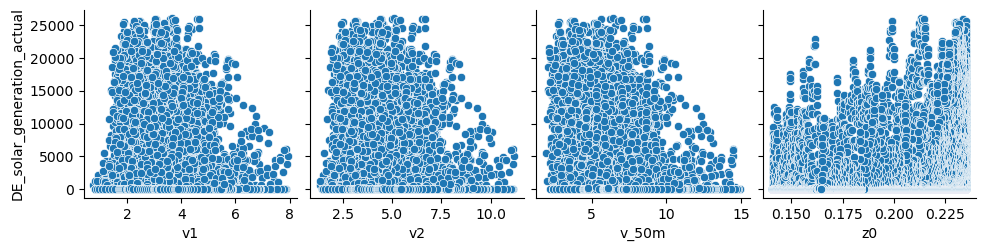

In [26]:
sns.pairplot(weather, x_vars=['v1', 'v2', 'v_50m', 'z0'], y_vars=['DE_solar_generation_actual'])


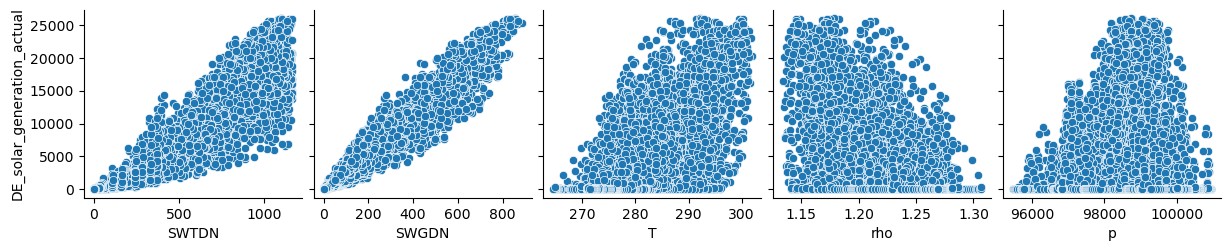

In [27]:
sns.pairplot(weather, x_vars=['SWTDN', 'SWGDN', 'T', 'rho', 'p'], y_vars=['DE_solar_generation_actual'])


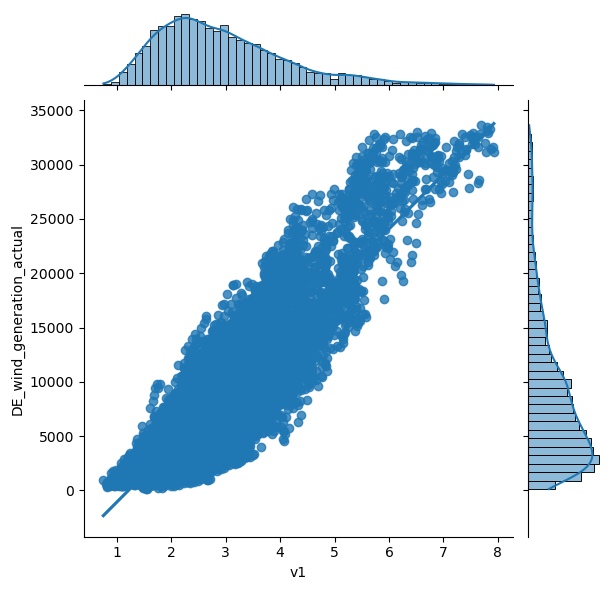

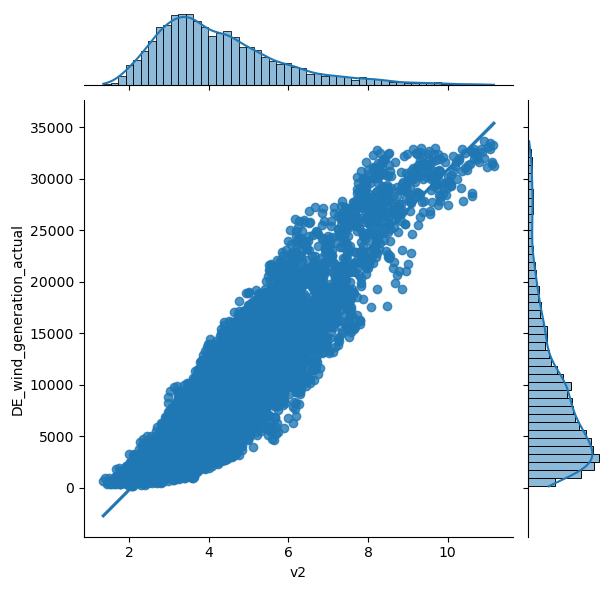

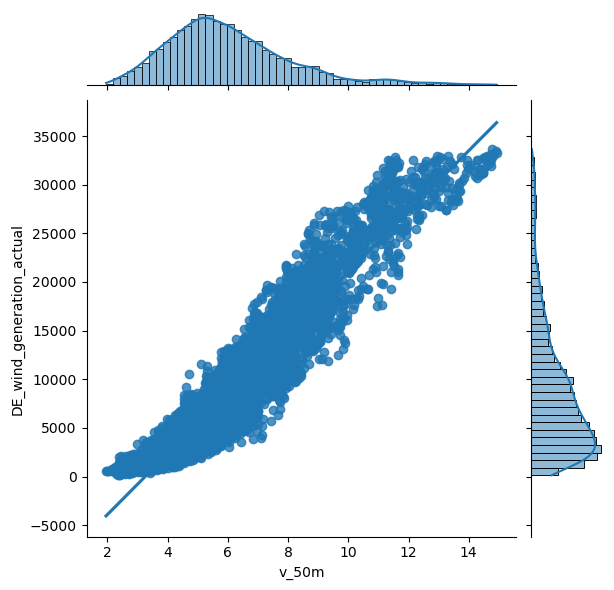

In [28]:
sns.jointplot(x='v1', y='DE_wind_generation_actual', data=weather, kind='reg')
sns.jointplot(x='v2', y='DE_wind_generation_actual', data=weather, kind='reg')
sns.jointplot(x='v_50m', y='DE_wind_generation_actual', data=weather, kind='reg')

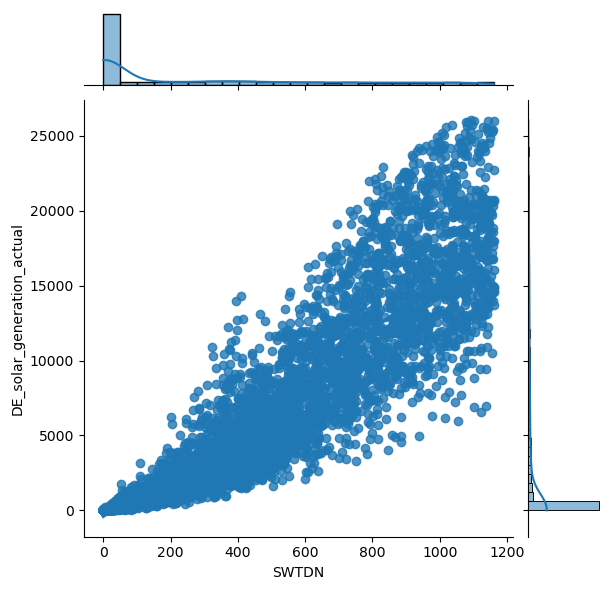

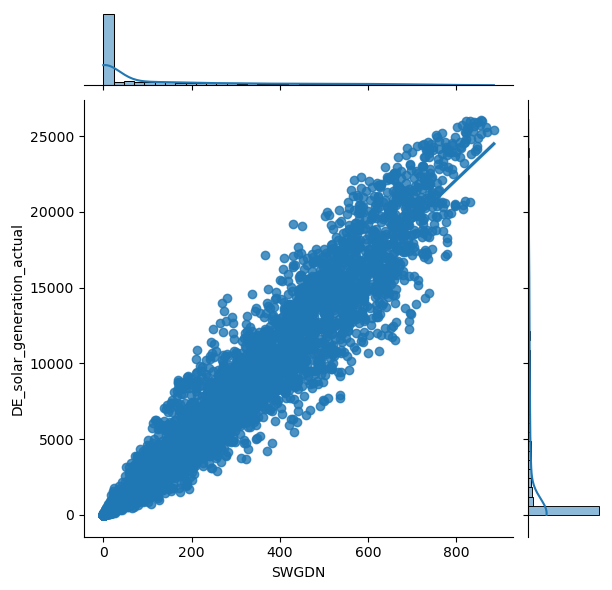

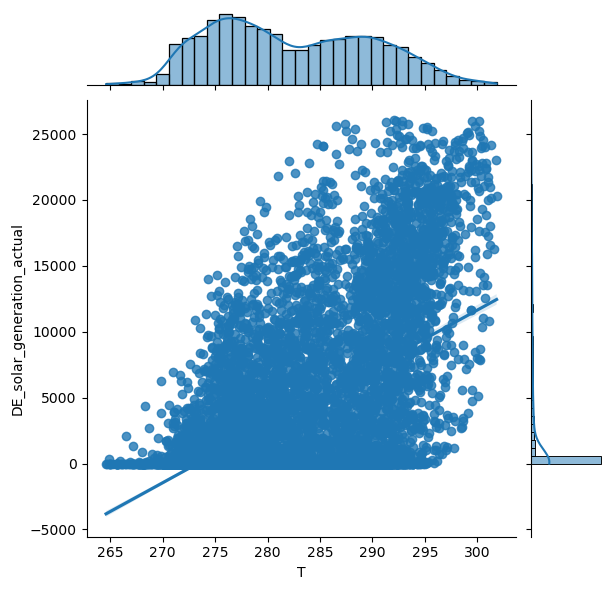

In [29]:
sns.jointplot(x='SWTDN', y='DE_solar_generation_actual', data=weather, kind='reg')
sns.jointplot(x='SWGDN', y='DE_solar_generation_actual', data=weather, kind='reg')
sns.jointplot(x='T', y='DE_solar_generation_actual', data=weather, kind='reg')

In [30]:
weather[['v1', 'v2', 'v_50m', 'z0', 'SWTDN', 'SWGDN', 'T', 'DE_wind_generation_actual', 'DE_solar_generation_actual']].describe()


,v1,v2,v_50m,z0,SWTDN,SWGDN,T,DE_wind_generation_actual,DE_solar_generation_actual
count,8711.000000,8711.000000,8711.000000,8711.000000,8711.000000,8711.000000,8711.000000,8711.000000,8711.000000
mean,2.941975,4.293732,6.050961,0.200228,278.129513,146.132596,282.367509,8717.896568,3945.663070
std,1.196953,1.613515,2.090007,0.032325,359.484347,212.562197,7.600127,6848.282483,6041.286172
min,0.746523,1.345508,1.958984,0.140880,0.000000,0.000000,264.596945,135.000000,0.000000
25%,2.068887,3.137734,4.626191,0.170419,0.000000,0.000000,276.035194,3587.000000,0.000000
50%,2.714648,3.942500,5.711445,0.211839,31.675276,7.862777,281.236115,6904.000000,123.000000
75%,3.574883,5.102070,7.084414,0.230067,523.363525,243.060669,288.706467,11703.500000,6287.500000
max,7.927695,11.164297,14.922969,0.235163,1160.939453,885.725586,301.845276,33626.000000,26055.000000


In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# instantiate LinearRegression
lr = LinearRegression()

In [32]:
X_wind = weather[['v1', 'v2', 'v_50m', 'z0']]
y_wind = weather['DE_wind_generation_actual']

In [33]:
scores_wind = cross_val_score(lr, X_wind, y_wind, cv=5)
print(scores_wind, "\naverage =", np.mean(scores_wind))


[0.84613194 0.88945167 0.81743091 0.88345643 0.85727051] 
average = 0.8587482924616264


In [34]:
X_solar = weather[['SWTDN', 'SWGDN', 'T']]
y_solar = weather['DE_solar_generation_actual']

In [35]:
scores_solar = cross_val_score(lr, X_solar, y_solar, cv=5)
print(scores_solar, "\naverage =", np.mean(scores_solar))

[0.88949312 0.9531631  0.95591896 0.95043991 0.87378194] 
average = 0.9245594063416434


In [36]:
X = weather[['v1', 'v2', 'v_50m', 'z0', 'SWTDN', 'SWGDN', 'T']]
y = weather['DE_solar_generation_actual'] + weather['DE_wind_generation_actual']

In [37]:
scores_overall = cross_val_score(lr, X, y, cv=5)
print(scores_solar, "\naverage =", np.mean(scores_overall))

[0.88949312 0.9531631  0.95591896 0.95043991 0.87378194] 
average = 0.8700296342416355


In [38]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8711 entries, 2016-01-01 00:00:00+00:00 to 2016-12-31 23:00:00+00:00
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   DE_wind_generation_actual   8711 non-null   float64
 1   DE_solar_generation_actual  8711 non-null   float64
 2   v1                          8711 non-null   float64
 3   v2                          8711 non-null   float64
 4   v_50m                       8711 non-null   float64
 5   h1                          8711 non-null   float64
 6   h2                          8711 non-null   float64
 7   z0                          8711 non-null   float64
 8   SWTDN                       8711 non-null   float64
 9   SWGDN                       8711 non-null   float64
 10  T                           8711 non-null   float64
 11  rho                         8711 non-null   float64
 12  p                           8711 non-null 